# 1. Import Dataset

In [1]:
!pip install rouge-score nltk

In [2]:
import os
import xml.etree.ElementTree as ET
import re
import json
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import AutoTokenizer, AutoModel
from torchvision import transforms, models

# Đổi path này thành path thực của bạn
DATA_PATH = "/home/jovyan/.cache/kagglehub/datasets/raddar/chest-xrays-indiana-university/versions/2"

# Kiểm tra cấu trúc thư mục
for root, dirs, files in os.walk(DATA_PATH):
    level = root.replace(DATA_PATH, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for f in files[:5]:
            print(f"{indent}  {f}")

2/
  indiana_projections.csv
  indiana_reports.csv
  images/
    images_normalized/


In [3]:
IMG_DIR   = os.path.join(DATA_PATH, "images/images_normalized")

# Load
reports     = pd.read_csv(os.path.join(DATA_PATH, "indiana_reports.csv"))
projections = pd.read_csv(os.path.join(DATA_PATH, "indiana_projections.csv"))

In [4]:
reports.info()
reports.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 3851 entries, 0 to 3850
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   uid         3851 non-null   int64
 1   MeSH        3851 non-null   str  
 2   Problems    3851 non-null   str  
 3   image       3851 non-null   str  
 4   indication  3765 non-null   str  
 5   comparison  2685 non-null   str  
 6   findings    3337 non-null   str  
 7   impression  3820 non-null   str  
dtypes: int64(1), str(7)
memory usage: 1.8 MB


,uid,MeSH,Problems,image,indication,comparison,findings,impression
0,1,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
1,2,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
2,3,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",NaN,NaN,"No displaced rib fractures, pneumothorax, or p..."
3,4,"Pulmonary Disease, Chronic Obstructive;Bullous...","Pulmonary Disease, Chronic Obstructive;Bullous...","PA and lateral views of the chest XXXX, XXXX a...",XXXX-year-old XXXX with XXXX.,None available,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...
4,5,Osteophyte/thoracic vertebrae/multiple/small;T...,Osteophyte;Thickening;Lung,Xray Chest PA and Lateral,Chest and nasal congestion.,NaN,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.
5,6,normal,normal,"PA and Lateral Chest. XXXX, XXXX at XXXX",Evaluate for infection,"XXXX, XXXX",Heart size and mediastinal contour are within ...,No acute cardiopulmonary findings.
6,7,Pulmonary Atelectasis/base;Spondylosis/thoraci...,Pulmonary Atelectasis;Spondylosis;Arthritis,Xray Chest PA and Lateral,Preop lumbar surgery,"XXXX, XXXX",The cardiac contours are normal. XXXX basilar ...,Basilar atelectasis. No confluent lobar consol...
7,8,normal,normal,Xray Chest PA and Lateral,XXXX-year-old with XXXX on XXXX. Dyspnea. Hist...,Two views of the chest dated XXXX.,"The heart, pulmonary XXXX and mediastinum are ...",No acute cardiopulmonary disease.
8,9,Calcified Granuloma/lung/upper lobe/right;Dens...,Calcified Granuloma;Density,Xray Chest PA and Lateral,Chest pain today. History of stent placement 7...,"CT XXXX image XXXX, CT abdomen which included ...",The XXXX examination consists of frontal and l...,Increased size of density in the left cardioph...
9,10,Calcified Granuloma/lung/upper lobe/right,Calcified Granuloma,PA and lateral chest x-XXXX XXXX.,"XXXX-year-old male, chest pain.",Chest radiographs XXXX.,The cardiomediastinal silhouette is within nor...,No acute cardiopulmonary process.


In [5]:
projections.info()
projections.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 7466 entries, 0 to 7465
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   uid         7466 non-null   int64
 1   filename    7466 non-null   str  
 2   projection  7466 non-null   str  
dtypes: int64(1), str(2)
memory usage: 408.7 KB


,uid,filename,projection
0,1,1_IM-0001-4001.dcm.png,Frontal
1,1,1_IM-0001-3001.dcm.png,Lateral
2,2,2_IM-0652-1001.dcm.png,Frontal
3,2,2_IM-0652-2001.dcm.png,Lateral
4,3,3_IM-1384-1001.dcm.png,Frontal
5,3,3_IM-1384-2001.dcm.png,Lateral
6,4,4_IM-2050-1001.dcm.png,Frontal
7,4,4_IM-2050-2001.dcm.png,Lateral
8,5,5_IM-2117-1003002.dcm.png,Frontal
9,5,5_IM-2117-1004003.dcm.png,Lateral


# 2. EDA

In [6]:
# ── 1. Thống kê missing values ──────────────────────────────────
print("=== Missing values (reports) ===")
print(reports.isnull().sum())
print(f"\nTotal records: {len(reports)}")

=== Missing values (reports) ===
uid              0
MeSH             0
Problems         0
image            0
indication      86
comparison    1166
findings       514
impression      31
dtype: int64

Total records: 3851


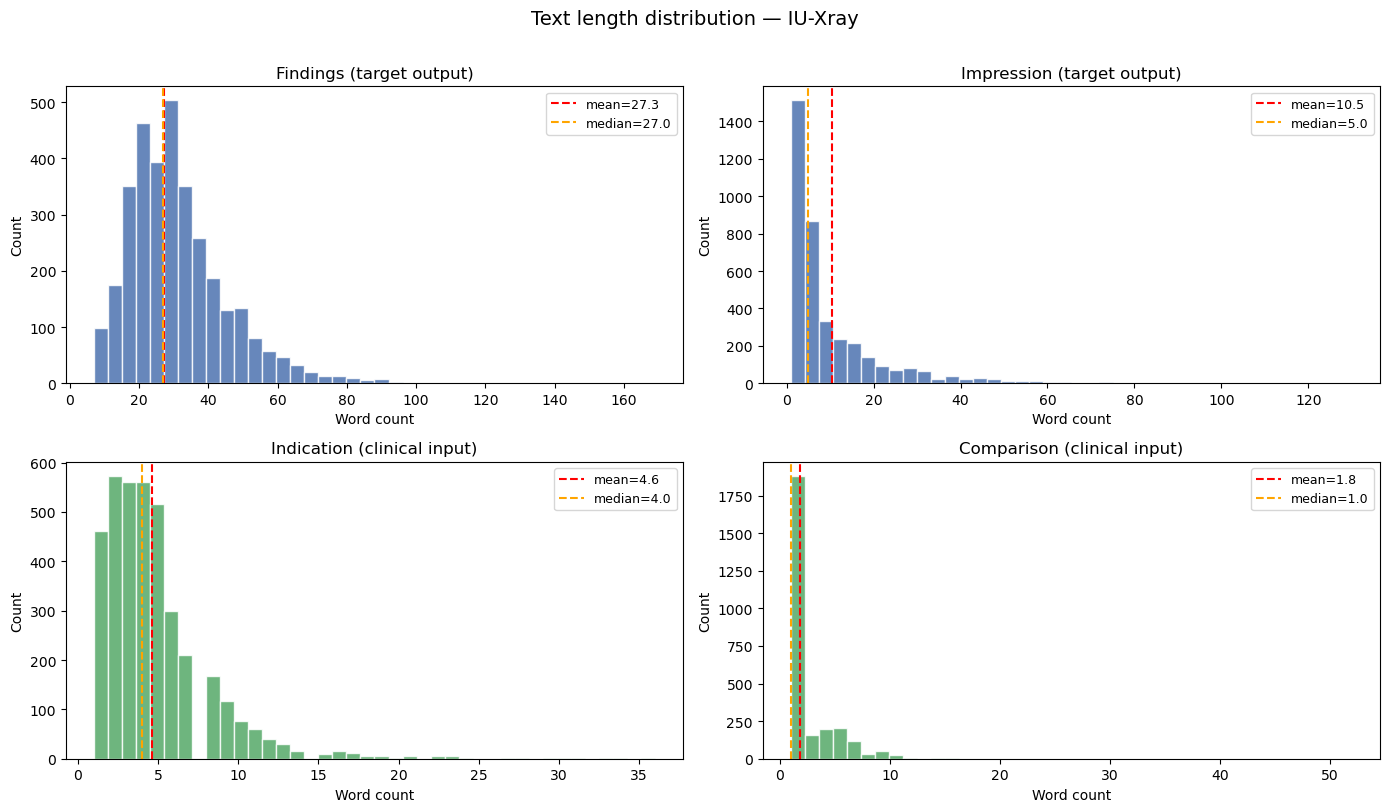

In [7]:
# ── 2. Phân phối độ dài text ────────────────────────────────────
for col in ['findings', 'impression', 'indication', 'comparison']:
    reports[f'{col}_len'] = reports[col].fillna('').apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
cols_info = [
    ('findings_len',   'Findings (target output)',       '#4C72B0'),
    ('impression_len', 'Impression (target output)',     '#4C72B0'),
    ('indication_len', 'Indication (clinical input)',    '#55A868'),
    ('comparison_len', 'Comparison (clinical input)',    '#55A868'),
]
for ax, (col, title, color) in zip(axes, cols_info):
    data = reports[col]
    ax.hist(data[data > 0], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'mean={data.mean():.1f}')
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.5,
               label=f'median={data.median():.1f}')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Word count')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
plt.suptitle('Text length distribution — IU-Xray', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [8]:
# ── 3. Projection distribution ──────────────────────────────────
proj_counts = projections['projection'].value_counts()
print("=== Projection types ===")
print(proj_counts)

# Số uid có đủ cả Frontal lẫn Lateral
both = projections.groupby('uid')['projection'].apply(set)
print(f"\nUIDs có cả Frontal+Lateral : {both.apply(lambda x: {'Frontal','Lateral'}.issubset(x)).sum()}")
print(f"UIDs chỉ có 1 ảnh          : {both.apply(lambda x: len(x)==1).sum()}")

=== Projection types ===
projection
Frontal    3818
Lateral    3648
Name: count, dtype: int64

UIDs có cả Frontal+Lateral : 3388
UIDs chỉ có 1 ảnh          : 463


In [9]:
# ── 4. Xem vài report mẫu ───────────────────────────────────────
print("=== Sample reports ===")
sample = reports[reports['findings'].notna()].sample(3, random_state=42)
for _, row in sample.iterrows():
    print(f"\n{'─'*60}")
    print(f"UID        : {row['uid']}")
    print(f"Indication : {str(row['indication'])}")
    print(f"Comparison : {str(row['comparison'])}")
    print(f"Findings   : {str(row['findings'])}")
    print(f"Impression : {str(row['impression'])}")

=== Sample reports ===

────────────────────────────────────────────────────────────
UID        : 376
Indication : Bladder cancer.
Comparison : XXXX.
Findings   : The heart size and pulmonary vascularity appear within normal limits. The lungs are free of focal airspace disease. No pleural effusion or pneumothorax is seen. No non-calcified nodules are identified.
Impression : 1. No evidence of active disease.

────────────────────────────────────────────────────────────
UID        : 3703
Indication : History of atrial fibrillation and cardioversion 3 weeks ago, heart XXXX.
Comparison : None.
Findings   : The XXXX examination consists of frontal and lateral radiographs of the chest. The posterior costophrenic XXXX are excluded on the lateral view. The cardiomediastinal contours are within normal limits. Pulmonary vascularity is within normal limits. No focal consolidation, pleural effusion, or pneumothorax identified. The visualized osseous structures and upper abdomen are unremarkable.


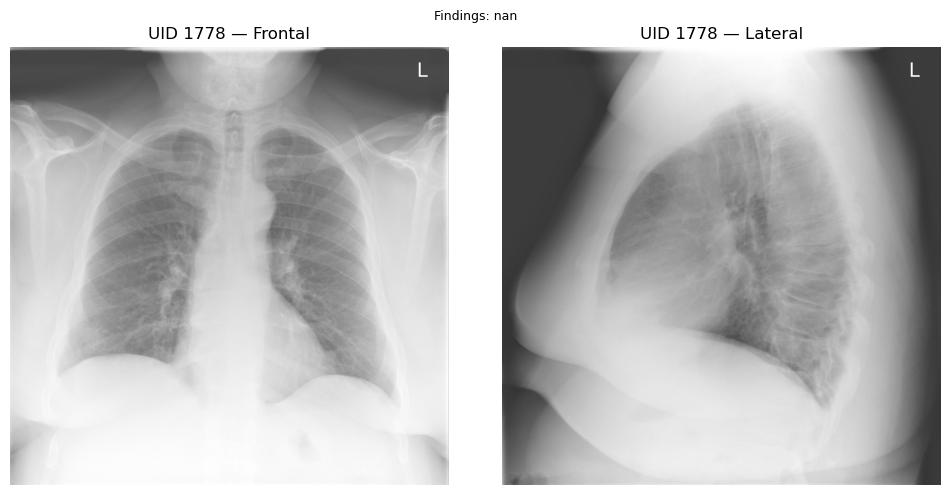

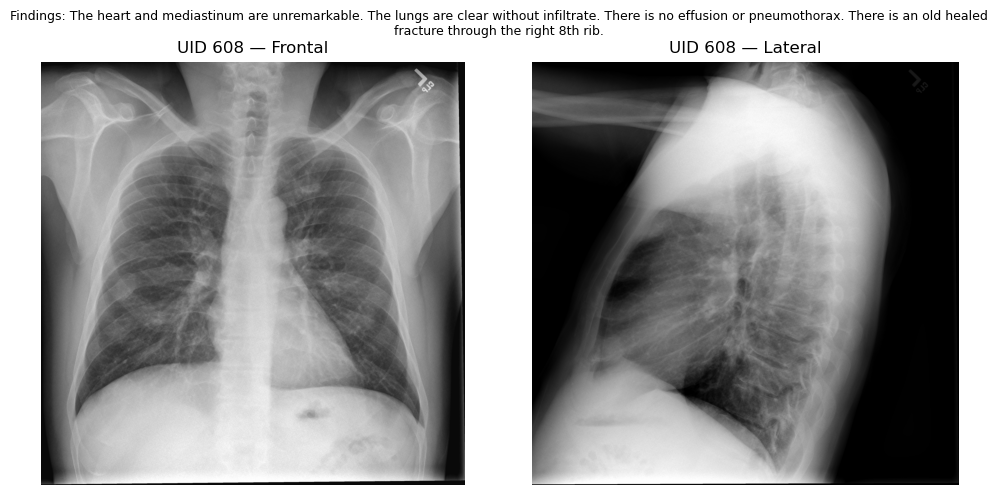

In [10]:
# ── 5. Hiển thị cặp ảnh Frontal + Lateral ───────────────────────
def show_sample_pair(uid, projections, img_dir):
    imgs = projections[projections['uid'] == uid]
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    for ax, (_, row) in zip(axes, imgs.iterrows()):
        fpath = os.path.join(img_dir, row['filename'])
        if os.path.exists(fpath):
            img = Image.open(fpath).convert('RGB')
            ax.imshow(img, cmap='gray')
            ax.set_title(f"UID {uid} — {row['projection']}")
        else:
            ax.set_title(f"File not found: {row['filename']}")
        ax.axis('off')
    report_row = reports[reports['uid'] == uid].iloc[0]
    fig.suptitle(f"Findings: {str(report_row['findings'])}",
                 fontsize=9, wrap=True)
    plt.tight_layout()
    plt.show()

# Lấy 2 uid ngẫu nhiên có đủ cả 2 ảnh
both_uids = both[both.apply(lambda x: {'Frontal','Lateral'}.issubset(x))].index.tolist()
for uid in np.random.choice(both_uids, 2, replace=False):
    show_sample_pair(uid, projections, IMG_DIR)

In [11]:
# ── 6. Kiểm tra ảnh có tồn tại trên disk không ──────────────────
all_files_on_disk = set(os.listdir(IMG_DIR))
missing = projections[~projections['filename'].isin(all_files_on_disk)]
print(f"Tổng ảnh trong projections.csv : {len(projections)}")
print(f"Ảnh có trên disk               : {projections['filename'].isin(all_files_on_disk).sum()}")
print(f"Ảnh bị thiếu                   : {len(missing)}")

Tổng ảnh trong projections.csv : 7466
Ảnh có trên disk               : 7466
Ảnh bị thiếu                   : 0


In [12]:
# ── 7. Tóm tắt EDA ──────────────────────────────────────────────
print("=" * 50)
print("EDA SUMMARY")
print("=" * 50)
print(f"Reports total          : {len(reports)}")
print(f"  - có findings        : {reports['findings'].notna().sum()}")
print(f"  - có impression      : {reports['impression'].notna().sum()}")
print(f"  - có indication      : {reports['indication'].notna().sum()}")
print(f"  - có comparison      : {reports['comparison'].notna().sum()}")
print(f"\nProjections total      : {len(projections)}")
print(f"  - Frontal            : {(projections['projection']=='Frontal').sum()}")
print(f"  - Lateral            : {(projections['projection']=='Lateral').sum()}")
print(f"\nTarget output (findings + impression):")
print(f"  findings  avg words  : {reports['findings_len'].mean():.1f}")
print(f"  impression avg words : {reports['impression_len'].mean():.1f}")
print(f"\nClinical text input:")
print(f"  indication avg words : {reports['indication_len'].mean():.1f}")
print(f"  comparison avg words : {reports['comparison_len'].mean():.1f}")

EDA SUMMARY
Reports total          : 3851
  - có findings        : 3337
  - có impression      : 3820
  - có indication      : 3765
  - có comparison      : 2685

Projections total      : 7466
  - Frontal            : 3818
  - Lateral            : 3648

Target output (findings + impression):
  findings  avg words  : 27.3
  impression avg words : 10.5

Clinical text input:
  indication avg words : 4.6
  comparison avg words : 1.8


# 3. Pre-processing

In [13]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from collections import Counter
import re
import json

# ── 1. Merge reports + projections ──────────────────────────────
# Pivot projections: mỗi uid thành 1 row có frontal_path + lateral_path
def build_image_map(projections, img_dir):
    result = {}
    for uid, group in projections.groupby('uid'):
        row = {'frontal': None, 'lateral': None}
        for _, r in group.iterrows():
            key = 'frontal' if r['projection'] == 'Frontal' else 'lateral'
            row[key] = os.path.join(img_dir, r['filename'])
        # Missing 1 view, duplicate other view
        if row['frontal'] is None:
            row['frontal'] = row['lateral']
        if row['lateral'] is None:
            row['lateral'] = row['frontal']
        result[uid] = row
    return result

image_map = build_image_map(projections, IMG_DIR)

# Merge vào reports
reports['frontal_path'] = reports['uid'].map(lambda u: image_map.get(u, {}).get('frontal'))
reports['lateral_path'] = reports['uid'].map(lambda u: image_map.get(u, {}).get('lateral'))

print(f"UIDs have images: {reports['frontal_path'].notna().sum()}")

UIDs have images: 3851


In [14]:
def clean_text(text):
    """Chỉ dùng cho TARGET text — đi qua vocab decoder"""
    if pd.isna(text) or str(text).strip() == '':
        return ''
    text = str(text).lower().strip()
    text = re.sub(r'[^\w\s\.\,\;\:\-\(\)\/]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Target → cần clean vì đi qua vocab thủ công
reports['findings_clean']   = reports['findings'].apply(clean_text)
reports['impression_clean'] = reports['impression'].apply(clean_text)
reports['target_text']      = reports.apply(
    lambda r: (r['findings_clean'] + ' ' + r['impression_clean']).strip(),
    axis=1
)

# Clinical text → No need to clean because go through ClinicalBERT
reports['clinical_text'] = reports.apply(
    lambda r: (str(r['indication'] if pd.notna(r['indication']) else '') 
               + ' ' + 
               str(r['comparison'] if pd.notna(r['comparison']) else '')).strip(),
    axis=1
)

In [15]:
# ── 3. Split TRƯỚC khi build vocab ──────────────────────────────
train_df, test_df = train_test_split(reports, test_size=0.2,   random_state=42)
train_df, val_df  = train_test_split(train_df, test_size=0.125, random_state=42)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 2695 | Val: 385 | Test: 771


In [16]:
# ── 4. Vocabulary chỉ cho TARGET (decoder output) ───────────────
# ClinicalBERT tự lo tokenize clinical text
# Chỉ cần build vocab cho phần decoder cần generate

class Vocabulary:
    PAD, SOS, EOS, UNK = 0, 1, 2, 3

    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.word2idx = {'<PAD>':0, '<SOS>':1, '<EOS>':2, '<UNK>':3}
        self.idx2word = {0:'<PAD>', 1:'<SOS>', 2:'<EOS>', 3:'<UNK>'}

    def build(self, texts):
        counter = Counter()
        for text in texts:
            counter.update(str(text).split())
        for word, freq in counter.items():
            if freq >= self.min_freq and word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx]  = word
        print(f"Vocab size (decoder): {len(self.word2idx)}")

    def encode(self, text, max_len=100):
        tokens = [self.SOS]
        for w in str(text).split()[:max_len - 2]:
            tokens.append(self.word2idx.get(w, self.UNK))
        tokens.append(self.EOS)
        return tokens

    def decode(self, indices):
        words = []
        for idx in indices:
            if idx == self.EOS: break
            if idx not in (self.PAD, self.SOS):
                words.append(self.idx2word.get(idx, '<UNK>'))
        return ' '.join(words)

    def save(self, path):
        with open(path, 'w') as f:
            json.dump(self.word2idx, f)

# Build từ train set target text
vocab = Vocabulary(min_freq=2)
vocab.build(train_df['target_text'].tolist())
vocab.save('vocab.json')

Vocab size (decoder): 1737


In [17]:
# ── 5. ClinicalBERT tokenizer cho clinical text ──────────────────
bert_tokenizer = AutoTokenizer.from_pretrained("medicalai/ClinicalBERT")

# Test thử để hiểu output
sample_text = "bladder cancer history of atrial fibrillation"
encoded = bert_tokenizer(
    sample_text,
    max_length=50,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)
print("input_ids shape     :", encoded['input_ids'].shape)
print("attention_mask shape:", encoded['attention_mask'].shape)
# attention_mask: 1 = real token, 0 = padding
# Model sẽ dùng mask này để không attend vào padding
print("\nTokens:")
print(bert_tokenizer.convert_ids_to_tokens(encoded['input_ids'][0]))

input_ids shape     : torch.Size([1, 50])
attention_mask shape: torch.Size([1, 50])

Tokens:
['[CLS]', 'blad', '##der', 'cancer', 'history', 'of', 'at', '##rial', 'fi', '##bri', '##llat', '##ion', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


In [18]:
# ── 6. Dataset tích hợp cả BERT tokenizer và vocab ──────────────
class IUXrayDataset(Dataset):
    def __init__(self, df, vocab, bert_tokenizer, transform,
                 max_target_len=100, max_clinical_len=50):
        self.df              = df
        self.vocab           = vocab
        self.bert_tokenizer  = bert_tokenizer
        self.transform       = transform
        self.max_target_len  = max_target_len
        self.max_clinical_len = max_clinical_len

    def __len__(self):
        return len(self.df)

    def _load_image(self, path):
        img = Image.open(path).convert('RGB')
        return self.transform(img)

    def _encode_target(self, text):
        tokens = self.vocab.encode(text, self.max_target_len)
        # Pad nếu ngắn hơn max_len
        tokens += [self.vocab.PAD] * (self.max_target_len - len(tokens))
        return torch.tensor(tokens[:self.max_target_len], dtype=torch.long)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ── Ảnh ──
        frontal = self._load_image(row['frontal_path'])
        lateral = self._load_image(row['lateral_path'])

        # ── Clinical text → BERT tokenize ──
        clinical_encoded = self.bert_tokenizer(
            row['clinical_text'] if row['clinical_text'] else '[PAD]',
            max_length=self.max_clinical_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        # Squeeze batch dim vì tokenizer trả về (1, seq_len)
        clinical_ids  = clinical_encoded['input_ids'].squeeze(0)       # (50,)
        clinical_mask = clinical_encoded['attention_mask'].squeeze(0)  # (50,)

        # ── Target report → vocab tokenize ──
        target = self._encode_target(row['target_text'])  # (100,)

        return {
            'frontal'       : frontal,        # (3, 256, 256)
            'lateral'       : lateral,        # (3, 256, 256)
            'clinical_ids'  : clinical_ids,   # (50,)  — BERT token ids
            'clinical_mask' : clinical_mask,  # (50,)  — 1=real, 0=pad
            'target'        : target,         # (100,) — decoder vocab ids
            'uid'           : row['uid'],
        }

In [19]:
# ── 7. Transforms + DataLoaders ─────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = IUXrayDataset(train_df, vocab, bert_tokenizer, train_transform)
val_dataset   = IUXrayDataset(val_df,   vocab, bert_tokenizer, val_transform)
test_dataset  = IUXrayDataset(test_df,  vocab, bert_tokenizer, val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")
print(f"Test batches : {len(test_loader)}")

Train batches: 169
Val batches  : 25
Test batches : 49


In [20]:
# ── 8. Sanity check ──────────────────────────────────────────────
# Khởi tạo model
VOCAB_SIZE = len(vocab.word2idx)
batch = next(iter(train_loader))

print("frontal shape       :", batch['frontal'].shape)        # (16, 3, 224, 224)
print("lateral shape       :", batch['lateral'].shape)        # (16, 3, 224, 224)
print("clinical_ids shape  :", batch['clinical_ids'].shape)   # (16, 50)
print("clinical_mask shape :", batch['clinical_mask'].shape)  # (16, 50)
print("target shape        :", batch['target'].shape)         # (16, 100)

# Decode thử 1 sample
print("\nClinical text (BERT decode):")
print(bert_tokenizer.decode(
    batch['clinical_ids'][0],
    skip_special_tokens=True
))

print("\nTarget report (vocab decode):")
print(vocab.decode(batch['target'][0].tolist()))

frontal shape       : torch.Size([16, 3, 224, 224])
lateral shape       : torch.Size([16, 3, 224, 224])
clinical_ids shape  : torch.Size([16, 50])
clinical_mask shape : torch.Size([16, 50])
target shape        : torch.Size([16, 100])

Clinical text (BERT decode):
xxxx and xxxx for about one xxxx, shortness of breath started 4 days ago, some chest pain.

Target report (vocab decode):
heart size and mediastinal contour normal. there is mild diffuse interstitial prominence, worse in the right lung base. this has developed in the interval, and may represent atypical pneumonia. more focal right base airspace disease may represent scar given the stability over <UNK> no lobar consolidation or effusion. no pneumothorax.


# 4. Model Implementation
#<img src="" style="height:600px;" />

In [21]:
# Chạy cell này sau khi connect lab
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

True
NVIDIA RTX 6000 Ada Generation
VRAM: 50.9 GB


In [22]:
class DenseNetEncoder(nn.Module):
    """
    Using DenseNet-121 as image encoder.
    Removing classifier head, remains feature extractor.
    Output: (B, N, embed_dim) — N patches of feature map
    """
    def __init__(self, embed_dim=256, pretrained=True):
        super().__init__()

        densenet = models.densenet121(pretrained=pretrained)

        # Giữ lại phần features, bỏ phần classifier
        # densenet.features output: (B, 1024, H/32, W/32)
        # Với input 224x224 → (B, 1024, 7, 7)
        self.features = densenet.features
        self.relu     = nn.ReLU(inplace=True)

        # Project từ 1024 về embed_dim
        # Lý do: cần cùng dim với text encoder để cross-attention
        self.proj = nn.Linear(1024, embed_dim)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        """
        x    : (B, 3, 224, 224)
        return: (B, 49, embed_dim)  — 7x7=49 spatial patches
        """
        feat = self.features(x)          # (B, 1024, 7, 7)
        feat = self.relu(feat)
        feat = feat.flatten(2)           # (B, 1024, 49)
        feat = feat.permute(0, 2, 1)     # (B, 49, 1024)
        feat = self.norm(self.proj(feat)) # (B, 49, embed_dim)
        return feat


class CrossViewAttention(nn.Module):
    """
    [NEW] Learning spatial correspondence between frontal và lateral view.
    """
    def __init__(self, embed_dim=256, num_heads=8, dropout=0.1):
        super().__init__()

        # Frontal query, lateral key/value
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True   # (B, seq, dim) thay vì (seq, B, dim)
        )
        self.norm    = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, frontal_feat, lateral_feat):
        """
        frontal_feat: (B, 49, embed_dim)
        lateral_feat: (B, 49, embed_dim)
        return      : (B, 49, embed_dim) — frontal enriched by lateral
        """
        # Query = frontal: "tôi đang nhìn vùng này, lateral có gì tương ứng?"
        # Key = Value = lateral
        attended, _ = self.cross_attn(
            query=frontal_feat,
            key=lateral_feat,
            value=lateral_feat
        )

        # Residual: giữ thông tin gốc + thêm cross-view info
        out = self.norm(frontal_feat + self.dropout(attended))
        return out


class DualViewEncoder(nn.Module):
    """
    Encode both 2 view then fuse.
    Share weights between 2 encoder because it all x-ray image.
    """
    def __init__(self, embed_dim=256, pretrained=True):
        super().__init__()

        # 1 encoder dùng chung cho cả frontal lẫn lateral
        # Lý do share: cùng loại ảnh X-ray, ít params hơn
        self.encoder        = DenseNetEncoder(embed_dim, pretrained)
        self.cross_view_att = CrossViewAttention(embed_dim)

    def forward(self, frontal, lateral):
        """
        frontal: (B, 3, 224, 224)
        lateral: (B, 3, 224, 224)
        return : (B, 49, embed_dim)
        """
        # Encode từng view
        front_feat = self.encoder(frontal)  # (B, 49, embed_dim)
        later_feat = self.encoder(lateral)  # (B, 49, embed_dim)

        # Frontal attend vào lateral
        fused = self.cross_view_att(front_feat, later_feat)
        # (B, 49, embed_dim)

        return fused

In [23]:
class ClinicalTextEncoder(nn.Module):
    """
    ClinicalBERT frozen for feature extractor.
    Small dataset -> no fine-tuning.
    Only train projection layer.
    """
    def __init__(self, embed_dim=256):
        super().__init__()

        self.bert = AutoModel.from_pretrained('medicalai/ClinicalBERT')

        # Freeze all BERT
        for param in self.bert.parameters():
            param.requires_grad = False

        # BERT hidden size = 768 → project into embed_dim
        self.proj = nn.Linear(768, embed_dim)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, input_ids, attention_mask):
        """
        input_ids    : (B, seq_len)    — BERT token ids
        attention_mask: (B, seq_len)   — 1=real, 0=padding
        return       : (B, seq_len, embed_dim)
        """
        # torch.no_grad() because BERT frozen
        with torch.no_grad():
            outputs = self.bert(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

        # last_hidden_state: (B, seq_len, 768)
        token_feat = outputs.last_hidden_state
        token_feat = self.norm(self.proj(token_feat))
        # (B, seq_len, embed_dim)

        return token_feat

In [24]:
import torch
import torch.nn as nn

class BidirectionalCrossAttention(nn.Module):
    """
    2 bước attention bắt chước cách radiologist làm việc:
    Bước 1: nhìn ảnh → hỏi text "vùng này liên quan đến gì?"
    Bước 2: đọc text → nhìn lại ảnh "triệu chứng này ở đâu?"
    """
    def __init__(self, embed_dim=256, num_heads=8, dropout=0.1):
        super().__init__()

        # Attention 1: image query, text key/value
        self.img_to_txt = nn.MultiheadAttention(
            embed_dim, num_heads,
            dropout=dropout,
            batch_first=True
        )

        # Attention 2: image query/value, updated text key
        self.txt_to_img = nn.MultiheadAttention(
            embed_dim, num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm1   = nn.LayerNorm(embed_dim)
        self.norm2   = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, img_feat, txt_feat, txt_mask=None):
        """
        img_feat: (B, 49, embed_dim)
        txt_feat: (B, seq_len, embed_dim)
        txt_mask: (B, seq_len) — attention_mask từ BERT, 1=real 0=pad
        return  : (B, 49, embed_dim) — fused Z
        """
        # PyTorch MultiheadAttention dùng True = ignore position
        # Nên cần đảo ngược mask: 0 (padding) → True (ignore)
        key_padding_mask = None
        if txt_mask is not None:
            key_padding_mask = (txt_mask == 0)  # (B, seq_len)

        # Bước 1: image attend vào text
        # "Nhìn vùng ảnh này, text nào liên quan?"
        txt_attended, _ = self.img_to_txt(
            query=img_feat,
            key=txt_feat,
            value=txt_feat,
            key_padding_mask=key_padding_mask
        )
        txt_attended = self.norm1(img_feat + self.dropout(txt_attended))

        # Bước 2: image attend vào chính nó, guided by text
        # "Sau khi đọc text, nhìn lại ảnh ở đâu?"
        img_attended, _ = self.txt_to_img(
            query=txt_attended,
            key=txt_attended,
            value=img_feat
        )
        Z = self.norm2(txt_attended + self.dropout(img_attended))
        # (B, 49, embed_dim)

        return Z


class DiseaseClassifier(nn.Module):
    """
    NN nhỏ predict 14 CheXpert disease labels từ fused features.
    Output dùng để tạo prefix tokens cho decoder.

    Input : Z (B, 49, embed_dim) — fused image+text
    Output: disease_prob (B, 14) — xác suất từng bệnh
            prefix_token (B, 1, embed_dim) — disease embedding
    """
    def __init__(self, embed_dim=256, num_labels=14, dropout=0.1):
        super().__init__()

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, num_labels),
            nn.Sigmoid()    # multi-label: mỗi label độc lập
        )

        # Mỗi label có 1 learnable embedding
        # Học trong quá trình train cùng với toàn bộ model
        self.label_embeddings = nn.Embedding(num_labels, embed_dim)
        self.norm             = nn.LayerNorm(embed_dim)

    def forward(self, Z):
        """
        Z: (B, 49, embed_dim)
        """
        # Pool 49 patches thành 1 vector để classify
        Z_pooled = Z.mean(dim=1)              # (B, embed_dim)

        # Predict disease probabilities
        disease_prob = self.classifier(Z_pooled)  # (B, 14)

        # Tạo prefix token: weighted sum của label embeddings
        # Label nào prob cao → contribute nhiều hơn vào prefix
        # (B, 14) x (14, embed_dim) = (B, embed_dim)
        prefix = torch.matmul(disease_prob,
                              self.label_embeddings.weight)
        prefix = self.norm(prefix)
        prefix = prefix.unsqueeze(1)          # (B, 1, embed_dim)

        return disease_prob, prefix

In [25]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    """
    Thêm thông tin vị trí cho decoder.
    Transformer không có thứ tự nên cần encode vị trí vào.
    Dùng sin/cos cố định theo paper Attention is All You Need.
    """
    def __init__(self, embed_dim, dropout=0.1, max_len=200):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        # Tính sẵn positional encoding
        pe       = torch.zeros(max_len, embed_dim)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, embed_dim, 2).float()
            * (-math.log(10000.0) / embed_dim)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)          # (1, max_len, embed_dim)

        # register_buffer: không phải parameter nhưng vẫn lưu vào state_dict
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (B, seq_len, embed_dim)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

In [26]:
class ReportDecoder(nn.Module):
    """
    Transformer decoder sinh report từng token một.
    Nhận context (prefix + fused features) và sinh text.
    """
    def __init__(self, vocab_size, embed_dim=256, num_heads=8,
                 num_layers=3, dropout=0.1, max_len=100):
        super().__init__()
        self.embed_dim = embed_dim
        self.max_len   = max_len

        # Token embedding: chuyển token index thành vector
        # padding_idx=0: PAD token không contribute vào gradient
        self.token_embed = nn.Embedding(
            vocab_size, embed_dim, padding_idx=0
        )

        # Positional encoding: cho decoder biết token đang ở vị trí nào
        # Transformer không có khái niệm thứ tự nên cần encode vào
        self.pos_encoding = PositionalEncoding(embed_dim, dropout)

        # Transformer decoder layer
        # norm_first=True: Pre-LayerNorm — stable hơn khi train
        # batch_first=True: input shape (B, seq, dim) thay vì (seq, B, dim)
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,  # feedforward size = 1024
            dropout=dropout,
            batch_first=True,
            norm_first=True
        )

        # Stack num_layers decoder layers lại
        self.transformer_decoder = nn.TransformerDecoder(
            decoder_layer,
            num_layers=num_layers
        )

        # Output projection: từ embed_dim về vocab_size
        # Để tính xác suất từng từ trong vocabulary
        self.output_proj = nn.Linear(embed_dim, vocab_size)
        self.dropout     = nn.Dropout(dropout)

    def forward(self, context, target_ids):
        """
        Train mode — dùng teacher forcing.
        context   : (B, 1+N, embed_dim) — prefix + fused patches
        target_ids: (B, seq_len)         — ground truth token ids
        return    : (B, seq_len, vocab_size) — logits
        """
        # Embed target tokens + thêm positional info
        tgt = self.token_embed(target_ids)  # (B, seq_len, embed_dim)
        tgt = self.pos_encoding(tgt)

        seq_len = target_ids.size(1)

        # Causal mask: token i chỉ được attend vào token 0..i-1
        # Tránh model "nhìn trước" token tương lai khi train
        # Shape: (seq_len, seq_len) — True = ignore position đó
        causal_mask = nn.Transformer.generate_square_subsequent_mask(
            seq_len, device=target_ids.device
        )

        # Padding mask: bỏ qua PAD tokens (index=0)
        # True = ignore, nên PAD==0 → True → bị ignore
        pad_mask = (target_ids == 0).bool()  # (B, seq_len)

        # Decoder:
        # - Self-attention: target attend vào chính nó (với causal mask)
        # - Cross-attention: target attend vào context (image + text features)
        out = self.transformer_decoder(
            tgt=tgt,
            memory=context,
            tgt_mask=causal_mask,
            tgt_key_padding_mask=pad_mask
        )  # (B, seq_len, embed_dim)

        # Project về vocab size để predict xác suất từng từ
        logits = self.output_proj(out)  # (B, seq_len, vocab_size)
        return logits

    @torch.no_grad()
    def generate(self, context, sos_idx, eos_idx, max_len=None):
        """
        Inference mode — greedy decoding.
        Không dùng teacher forcing.
        Sinh từng token dựa trên token trước đó.

        context : (B, 1+N, embed_dim)
        return  : (B, seq_len) — generated token ids
        """
        if max_len is None:
            max_len = self.max_len

        B      = context.size(0)
        device = context.device

        # Bắt đầu với SOS token cho toàn bộ batch
        tokens = torch.full(
            (B, 1), sos_idx,
            dtype=torch.long, device=device
        )  # (B, 1)

        for _ in range(max_len - 1):
            # Forward pass với tokens đã sinh được
            logits = self.forward(context, tokens)
            # (B, current_len, vocab_size)

            # Lấy token có xác suất cao nhất ở vị trí cuối
            next_tok = logits[:, -1, :].argmax(dim=-1, keepdim=True)
            # (B, 1)

            # Append token mới vào sequence
            tokens = torch.cat([tokens, next_tok], dim=1)
            # (B, current_len + 1)

            # Dừng sớm nếu tất cả sequence đã sinh EOS
            if (next_tok == eos_idx).all():
                break

        return tokens  # (B, seq_len)

In [27]:
class MedicalReportModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=256,
                 num_labels=14, dropout=0.1):
        super().__init__()

        self.image_encoder = DualViewEncoder(embed_dim)
        self.text_encoder  = ClinicalTextEncoder(embed_dim)
        self.cross_attn    = BidirectionalCrossAttention(embed_dim,
                                                         dropout=dropout)
        self.disease_cls   = DiseaseClassifier(embed_dim,
                                               num_labels, dropout)
        self.decoder       = ReportDecoder(vocab_size, embed_dim,
                                           dropout=dropout)

    def forward(self, frontal, lateral,
                clinical_ids, clinical_mask,
                target_ids):
        """
        Train forward pass.

        frontal      : (B, 3, 224, 224)
        lateral      : (B, 3, 224, 224)
        clinical_ids : (B, seq_len)
        clinical_mask: (B, seq_len)
        target_ids   : (B, target_len)

        return:
            logits      : (B, target_len-1, vocab_size)
            disease_prob: (B, 14)
        """
        # 1. Encode
        img_feat = self.image_encoder(frontal, lateral)
        # (B, 49, embed_dim)

        txt_feat = self.text_encoder(clinical_ids, clinical_mask)
        # (B, seq_len, embed_dim)

        # 2. Cross-modal fusion
        Z = self.cross_attn(img_feat, txt_feat, clinical_mask)
        # (B, 49, embed_dim)

        # 3. Disease classifier → prefix token
        disease_prob, prefix = self.disease_cls(Z)
        # disease_prob: (B, 14)
        # prefix      : (B, 1, embed_dim)

        # 4. Assemble context
        context = torch.cat([prefix, Z], dim=1)
        # (B, 1+49, embed_dim) = (B, 50, embed_dim)

        # 5. Decode với teacher forcing
        # Input : target[:-1] — bỏ token cuối
        # Label : target[1:]  — bỏ SOS ở đầu (dùng trong loss)
        logits = self.decoder(context, target_ids[:, :-1])
        # (B, target_len-1, vocab_size)

        return logits, disease_prob

    @torch.no_grad()
    def generate(self, frontal, lateral,
                 clinical_ids, clinical_mask,
                 sos_idx, eos_idx, max_len=100):
        """Inference — không teacher forcing"""
        img_feat     = self.image_encoder(frontal, lateral)
        txt_feat     = self.text_encoder(clinical_ids, clinical_mask)
        Z            = self.cross_attn(img_feat, txt_feat, clinical_mask)
        _, prefix    = self.disease_cls(Z)
        context      = torch.cat([prefix, Z], dim=1)

        return self.decoder.generate(context, sos_idx, eos_idx, max_len)

In [28]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

# ── Config ───────────────────────────────────────────────────────
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPOCHS     = 30
LR         = 3e-4
LAMBDA_DIS = 0.3   # weight của disease loss
GRAD_CLIP  = 1.0   # gradient clipping để tránh exploding gradient

# Khởi tạo model với BERT vocab size
model = MedicalReportModel(
    vocab_size=VOCAB_SIZE   # 28996 thay vì ~2000
).to(DEVICE)

# Decode khi generate — dùng BERT tokenizer thay vì vocab.decode
def decode_output(token_ids):
    return bert_tokenizer.decode(
        token_ids,
        skip_special_tokens=True   # tự bỏ [CLS], [SEP], [PAD]
    )

# Chỉ optimize trainable params — BERT frozen không update
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4
)

# Cosine annealing: LR giảm dần theo hình cosine
# Tốt hơn step decay vì smooth hơn
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

/opt/conda/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: medicalai/ClinicalBERT
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [29]:
# ── Loss functions ───────────────────────────────────────────────

def compute_report_loss(logits, target_ids):
    """
    Cross-entropy loss cho report generation.

    logits    : (B, seq_len-1, vocab_size)
    target_ids: (B, seq_len)

    Teacher forcing:
      input  = target[:-1]  (bỏ token cuối)
      label  = target[1:]   (bỏ SOS ở đầu)
    """
    # Label = target bỏ SOS
    labels = target_ids[:, 1:].contiguous()   # (B, seq_len-1)

    # Reshape để tính cross entropy
    # logits: (B * (seq_len-1), vocab_size)
    # labels: (B * (seq_len-1),)
    loss = nn.CrossEntropyLoss(ignore_index=0)(  # ignore PAD=0
        logits.reshape(-1, logits.size(-1)),
        labels.reshape(-1)
    )
    return loss


def compute_disease_loss(disease_prob, disease_labels):
    """
    Binary cross-entropy cho disease classification.
    Multi-label nên dùng BCE, không phải CE.

    disease_prob  : (B, 14) — predicted probabilities
    disease_labels: (B, 14) — ground truth 0/1
    """
    loss = nn.BCELoss()(disease_prob, disease_labels.float())
    return loss

In [30]:
# ── Prepare disease labels từ CheXpert labeler ───────────────────
# Dùng negbio hoặc chexpert-labeler để tag 14 labels từ report text
# Ở đây dùng simple keyword matching để demo
# Trong thực tế nên dùng: pip install chexpert-labeler

CHEXPERT_LABELS = [
    'atelectasis', 'cardiomegaly', 'consolidation', 'edema',
    'enlarged cardiomediastinum', 'fracture', 'lung lesion',
    'lung opacity', 'no finding', 'pleural effusion',
    'pleural other', 'pneumonia', 'pneumothorax', 'support devices'
]

def get_disease_labels(text, labels=CHEXPERT_LABELS):
    """
    Simple keyword matching để tạo disease labels.
    0 = absent, 1 = present
    """
    text  = str(text).lower()
    result = []
    for label in labels:
        # Kiểm tra từ khóa xuất hiện trong text
        # Xử lý negation đơn giản: "no atelectasis" → 0
        keyword = label.split()[-1]   # lấy từ cuối
        if keyword in text:
            # Kiểm tra negation
            idx = text.find(keyword)
            context = text[max(0, idx-20):idx]
            if any(neg in context for neg in ['no ', 'without ', 'clear']):
                result.append(0)
            else:
                result.append(1)
        else:
            result.append(0)
    return result

# Tạo disease label columns cho các splits
for df in [train_df, val_df, test_df]:
    df['disease_labels'] = df['target_text'].apply(get_disease_labels)

In [31]:
# ── Cập nhật Dataset để trả về disease_labels ────────────────────
class IUXrayDataset(Dataset):
    def __init__(self, df, vocab, bert_tokenizer, transform,
                 max_target_len=100, max_clinical_len=50):
        self.df               = df
        self.vocab            = vocab
        self.bert_tokenizer   = bert_tokenizer
        self.transform        = transform
        self.max_target_len   = max_target_len
        self.max_clinical_len = max_clinical_len

    def __len__(self):
        return len(self.df)

    def _load_image(self, path):
        return self.transform(Image.open(path).convert('RGB'))

    def _encode_target(self, text):
        tokens  = self.vocab.encode(text, self.max_target_len)
        tokens += [self.vocab.PAD] * (self.max_target_len - len(tokens))
        return torch.tensor(tokens[:self.max_target_len], dtype=torch.long)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        frontal = self._load_image(row['frontal_path'])
        lateral = self._load_image(row['lateral_path'])

        clinical_encoded = self.bert_tokenizer(
            row['clinical_text'] if row['clinical_text'].strip() else '[PAD]',
            max_length=self.max_clinical_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        clinical_ids  = clinical_encoded['input_ids'].squeeze(0)
        clinical_mask = clinical_encoded['attention_mask'].squeeze(0)

        target = self._encode_target(row['target_text'])

        # Disease labels — (14,) binary vector
        disease_labels = torch.tensor(
            row['disease_labels'], dtype=torch.float
        )

        return {
            'frontal'        : frontal,
            'lateral'        : lateral,
            'clinical_ids'   : clinical_ids,
            'clinical_mask'  : clinical_mask,
            'target'         : target,
            'disease_labels' : disease_labels,
        }

In [32]:
# Tạo lại DataLoaders
train_dataset = IUXrayDataset(train_df, vocab, bert_tokenizer, train_transform)
val_dataset   = IUXrayDataset(val_df,   vocab, bert_tokenizer, val_transform)
test_dataset  = IUXrayDataset(test_df,  vocab, bert_tokenizer, val_transform)

# Tăng shared memory limit trước
import subprocess
subprocess.run(['mount', '-o', 'remount,size=16G', '/dev/shm'],
               capture_output=True)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False,
                          num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False,
                          num_workers=0, pin_memory=False)

In [33]:
# ── Training + Validation loop ───────────────────────────────────
import time

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = total_report = total_disease = 0

    for batch in loader:
        frontal        = batch['frontal'].to(DEVICE)
        lateral        = batch['lateral'].to(DEVICE)
        clinical_ids   = batch['clinical_ids'].to(DEVICE)
        clinical_mask  = batch['clinical_mask'].to(DEVICE)
        target         = batch['target'].to(DEVICE)
        disease_labels = batch['disease_labels'].to(DEVICE)

        optimizer.zero_grad()

        logits, disease_prob = model(
            frontal, lateral,
            clinical_ids, clinical_mask,
            target
        )

        # Tính 2 losses
        report_loss  = compute_report_loss(logits, target)
        disease_loss = compute_disease_loss(disease_prob, disease_labels)
        loss         = report_loss + LAMBDA_DIS * disease_loss

        loss.backward()

        # Gradient clipping: tránh gradient quá lớn làm model diverge
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        optimizer.step()

        total_loss    += loss.item()
        total_report  += report_loss.item()
        total_disease += disease_loss.item()

    n = len(loader)
    return total_loss/n, total_report/n, total_disease/n


@torch.no_grad()
def val_epoch(model, loader):
    model.eval()
    total_loss = total_report = total_disease = 0

    for batch in loader:
        frontal        = batch['frontal'].to(DEVICE)
        lateral        = batch['lateral'].to(DEVICE)
        clinical_ids   = batch['clinical_ids'].to(DEVICE)
        clinical_mask  = batch['clinical_mask'].to(DEVICE)
        target         = batch['target'].to(DEVICE)
        disease_labels = batch['disease_labels'].to(DEVICE)

        logits, disease_prob = model(
            frontal, lateral,
            clinical_ids, clinical_mask,
            target
        )

        report_loss  = compute_report_loss(logits, target)
        disease_loss = compute_disease_loss(disease_prob, disease_labels)
        loss         = report_loss + LAMBDA_DIS * disease_loss

        total_loss    += loss.item()
        total_report  += report_loss.item()
        total_disease += disease_loss.item()

    n = len(loader)
    return total_loss/n, total_report/n, total_disease/n

In [34]:
# ── Main training ─────────────────────────────────────────────────
best_val_loss = float('inf')
history       = []

print(f"{'Epoch':>5} | {'Train':>8} | {'Val':>8} | "
      f"{'Rep':>7} | {'Dis':>7} | {'Time':>6}")
print("─" * 55)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss, train_rep, train_dis = train_epoch(
        model, train_loader, optimizer)
    val_loss, val_rep, val_dis       = val_epoch(
        model, val_loader)

    scheduler.step()
    elapsed = time.time() - t0

    history.append({
        'epoch'      : epoch,
        'train_loss' : train_loss,
        'val_loss'   : val_loss,
        'train_rep'  : train_rep,
        'val_rep'    : val_rep,
    })

    print(f"{epoch:>5} | {train_loss:>8.4f} | {val_loss:>8.4f} | "
          f"{val_rep:>7.4f} | {val_dis:>7.4f} | {elapsed:>5.0f}s")

    # Save checkpoint tốt nhất dựa trên val_loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch'     : epoch,
            'model'     : model.state_dict(),
            'optimizer' : optimizer.state_dict(),
            'val_loss'  : val_loss,
            'vocab'     : vocab.word2idx,
        }, 'best_model.pt')
        print(f"Saved checkpoint (val_loss={val_loss:.4f})")

Epoch |    Train |      Val |     Rep |     Dis |   Time
───────────────────────────────────────────────────────


/opt/conda/lib/python3.13/site-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(
/opt/conda/lib/python3.13/site-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


    1 |   4.0159 |   3.0507 |  2.9749 |  0.2527 |   185s
Saved checkpoint (val_loss=3.0507)
    2 |   2.9131 |   2.6738 |  2.6007 |  0.2434 |   184s
Saved checkpoint (val_loss=2.6738)
    3 |   2.5340 |   2.5016 |  2.4301 |  0.2380 |   184s
Saved checkpoint (val_loss=2.5016)
    4 |   2.3083 |   2.4104 |  2.3393 |  0.2369 |   184s
Saved checkpoint (val_loss=2.4104)
    5 |   2.1346 |   2.3196 |  2.2496 |  0.2334 |   184s
Saved checkpoint (val_loss=2.3196)
    6 |   1.9922 |   2.3200 |  2.2493 |  0.2358 |   184s
    7 |   1.8628 |   2.2776 |  2.2083 |  0.2311 |   184s
Saved checkpoint (val_loss=2.2776)
    8 |   1.7398 |   2.2701 |  2.2018 |  0.2278 |   184s
Saved checkpoint (val_loss=2.2701)
    9 |   1.6361 |   2.2399 |  2.1714 |  0.2284 |   184s
Saved checkpoint (val_loss=2.2399)
   10 |   1.5317 |   2.2596 |  2.1922 |  0.2245 |   184s
   11 |   1.4293 |   2.2629 |  2.1956 |  0.2244 |   184s
   12 |   1.3525 |   2.2687 |  2.2019 |  0.2225 |   184s
   13 |   1.2673 |   2.3028 |  2.235

In [35]:
# pip install nltk rouge-score
import nltk
nltk.download('punkt')
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer

@torch.no_grad()
def evaluate(model, loader, vocab, max_len=100):
    """
    Generate reports cho toàn bộ test set
    rồi tính BLEU-1,2,3,4 và ROUGE-L
    """
    model.eval()

    all_hypotheses = []   # generated reports
    all_references = []   # ground truth reports

    for batch in loader:
        frontal       = batch['frontal'].to(DEVICE)
        lateral       = batch['lateral'].to(DEVICE)
        clinical_ids  = batch['clinical_ids'].to(DEVICE)
        clinical_mask = batch['clinical_mask'].to(DEVICE)
        target        = batch['target']   # giữ trên CPU

        # Generate
        generated = model.generate(
            frontal, lateral,
            clinical_ids, clinical_mask,
            sos_idx=vocab.SOS,
            eos_idx=vocab.EOS,
            max_len=max_len
        )  # (B, seq_len)

        for i in range(len(generated)):
            # Decode generated tokens
            hyp = vocab.decode(generated[i].cpu().tolist())
            ref = vocab.decode(target[i].tolist())

            all_hypotheses.append(hyp.split())
            all_references.append([ref.split()])

    # BLEU scores
    smooth = SmoothingFunction().method1
    bleu1  = corpus_bleu(all_references, all_hypotheses,
                         weights=(1,0,0,0), smoothing_function=smooth)
    bleu2  = corpus_bleu(all_references, all_hypotheses,
                         weights=(0.5,0.5,0,0), smoothing_function=smooth)
    bleu3  = corpus_bleu(all_references, all_hypotheses,
                         weights=(0.33,0.33,0.33,0), smoothing_function=smooth)
    bleu4  = corpus_bleu(all_references, all_hypotheses,
                         weights=(0.25,0.25,0.25,0.25), smoothing_function=smooth)

    # ROUGE-L
    scorer   = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    rouge_ls = []
    for hyp, refs in zip(all_hypotheses, all_references):
        score = scorer.score(' '.join(refs[0]), ' '.join(hyp))
        rouge_ls.append(score['rougeL'].fmeasure)
    rougeL = sum(rouge_ls) / len(rouge_ls)

    return {
        'BLEU-1' : bleu1,
        'BLEU-2' : bleu2,
        'BLEU-3' : bleu3,
        'BLEU-4' : bleu4,
        'ROUGE-L': rougeL,
    }


# Load best checkpoint rồi evaluate
checkpoint = torch.load('best_model.pt')
model.load_state_dict(checkpoint['model'])

print("Evaluating on test set...")
results = evaluate(model, test_loader, vocab)

print("\n=== Test Results ===")
for metric, score in results.items():
    print(f"{metric:>8}: {score:.4f}")

[nltk_data] Downloading package punkt to /home/jovyan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Evaluating on test set...


/opt/conda/lib/python3.13/site-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(



=== Test Results ===
  BLEU-1: 0.3152
  BLEU-2: 0.2267
  BLEU-3: 0.1805
  BLEU-4: 0.1475
 ROUGE-L: 0.3584


In [37]:
@torch.no_grad()
def show_samples(model, dataset, vocab, n=3):
    model.eval()
    indices = torch.randint(len(dataset), (n,)).tolist()

    for idx in indices:
        sample = dataset[idx]

        frontal = sample['frontal'].unsqueeze(0).to(DEVICE)
        lateral = sample['lateral'].unsqueeze(0).to(DEVICE)
        clin_ids  = sample['clinical_ids'].unsqueeze(0).to(DEVICE)
        clin_mask = sample['clinical_mask'].unsqueeze(0).to(DEVICE)

        generated = model.generate(
            frontal, lateral, clin_ids, clin_mask,
            sos_idx=vocab.SOS, eos_idx=vocab.EOS
        )

        print("─" * 60)
        print("Clinical text:")
        print(bert_tokenizer.decode(
            sample['clinical_ids'], skip_special_tokens=True))
        print("\nGround truth:")
        print(vocab.decode(sample['target'].tolist()))
        print("\nGenerated:")
        print(vocab.decode(generated[0].cpu().tolist()))

show_samples(model, test_dataset, vocab)

────────────────────────────────────────────────────────────
Clinical text:
xxxx - year - old with xxxx, history of lung nodules. xxxx performed xxxx / xxxx

Ground truth:
no focal lung consolidation. no pneumothorax or pleural <UNK> size and pulmonary vascularity are within normal <UNK> degenerative changes of the thoracic spine. the previously <UNK> described xxxx deformity in the midthoracic spine is again seen. there is subcutaneous shunt catheter tubing along the anterior chest wall no acute cardiopulmonary process.

Generated:
the heart size is normal. the mediastinal contour is within normal limits. the lungs are free of any focal infiltrates. there are no nodules or masses. no visible pneumothorax. no visible pleural fluid. the xxxx are grossly normal. there is no visible free intraperitoneal air under the diaphragm. 1. no acute radiographic cardiopulmonary process.
────────────────────────────────────────────────────────────
Clinical text:
chest pain xxxx, xxxx

Ground truth:


In [38]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms

def get_gradcam(model, frontal_tensor, lateral_tensor,
                clinical_ids, clinical_mask):
    """
    Tính GradCAM từ DenseNet features.
    Gradient của disease prediction so với feature map cuối.
    """
    model.eval()

    # Hook để lấy feature map và gradient
    features     = {}
    gradients    = {}

    def forward_hook(module, input, output):
        features['feat'] = output

    def backward_hook(module, grad_in, grad_out):
        gradients['grad'] = grad_out[0]

    # Attach hooks vào layer cuối của DenseNet features
    target_layer = model.image_encoder.encoder.features.denseblock4
    fwd_handle   = target_layer.register_forward_hook(forward_hook)
    bwd_handle   = target_layer.register_full_backward_hook(backward_hook)

    # Forward pass — cần gradient nên không dùng no_grad
    frontal       = frontal_tensor.unsqueeze(0).to(DEVICE)
    lateral       = lateral_tensor.unsqueeze(0).to(DEVICE)
    clin_ids      = clinical_ids.unsqueeze(0).to(DEVICE)
    clin_mask     = clinical_mask.unsqueeze(0).to(DEVICE)

    img_feat     = model.image_encoder(frontal, lateral)
    txt_feat     = model.text_encoder(clin_ids, clin_mask)
    Z            = model.cross_attn(img_feat, txt_feat, clin_mask)
    disease_prob, _ = model.disease_cls(Z)

    # Backward với score tổng các disease predictions
    model.zero_grad()
    score = disease_prob.sum()
    score.backward()

    # Tính GradCAM
    grad = gradients['grad']      # (1, C, H, W)
    feat = features['feat']       # (1, C, H, W)

    # Global average pooling của gradient → weights
    weights = grad.mean(dim=[2, 3], keepdim=True)  # (1, C, 1, 1)

    # Weighted sum của feature maps
    cam = (weights * feat).sum(dim=1, keepdim=True)  # (1, 1, H, W)
    cam = torch.relu(cam)                             # chỉ giữ positive
    cam = cam.squeeze().cpu().detach().numpy()

    # Normalize về 0-1
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    # Remove hooks
    fwd_handle.remove()
    bwd_handle.remove()

    return cam


def show_gradcam(model, dataset, vocab, idx=None):
    """
    Hiển thị ảnh gốc, heatmap GradCAM, và report generated.
    """
    if idx is None:
        idx = torch.randint(len(dataset), (1,)).item()

    sample = dataset[idx]

    # Tính GradCAM
    cam = get_gradcam(
        model,
        sample['frontal'],
        sample['lateral'],
        sample['clinical_ids'],
        sample['clinical_mask']
    )

    # Resize heatmap về kích thước ảnh gốc (224x224)
    cam_resized = cv2.resize(cam, (224, 224))
    heatmap     = cv2.applyColorMap(
        np.uint8(255 * cam_resized), cv2.COLORMAP_JET
    )
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Denormalize ảnh gốc để hiển thị
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = sample['frontal'].permute(1, 2, 0).numpy()
    img  = (img * std + mean).clip(0, 1)

    # Overlay heatmap lên ảnh
    overlay = 0.6 * img + 0.4 * heatmap / 255.0
    overlay = overlay.clip(0, 1)

    # Generate report
    model.eval()
    with torch.no_grad():
        generated = model.generate(
            sample['frontal'].unsqueeze(0).to(DEVICE),
            sample['lateral'].unsqueeze(0).to(DEVICE),
            sample['clinical_ids'].unsqueeze(0).to(DEVICE),
            sample['clinical_mask'].unsqueeze(0).to(DEVICE),
            sos_idx=vocab.SOS,
            eos_idx=vocab.EOS
        )

    gen_text = vocab.decode(generated[0].cpu().tolist())
    ref_text = vocab.decode(sample['target'].tolist())
    clin_text = bert_tokenizer.decode(
        sample['clinical_ids'], skip_special_tokens=True)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img)
    axes[0].set_title('Frontal X-ray', fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(heatmap)
    axes[1].set_title('GradCAM heatmap', fontsize=12)
    axes[1].axis('off')

    axes[2].imshow(overlay)
    axes[2].set_title('Overlay', fontsize=12)
    axes[2].axis('off')

    plt.suptitle(
        f"Clinical: {clin_text}\n"
        f"GT: {ref_text}\n"
        f"Generated: {gen_text}",
        fontsize=9, wrap=True
    )
    plt.tight_layout()
    plt.show()

Sample idx: 598


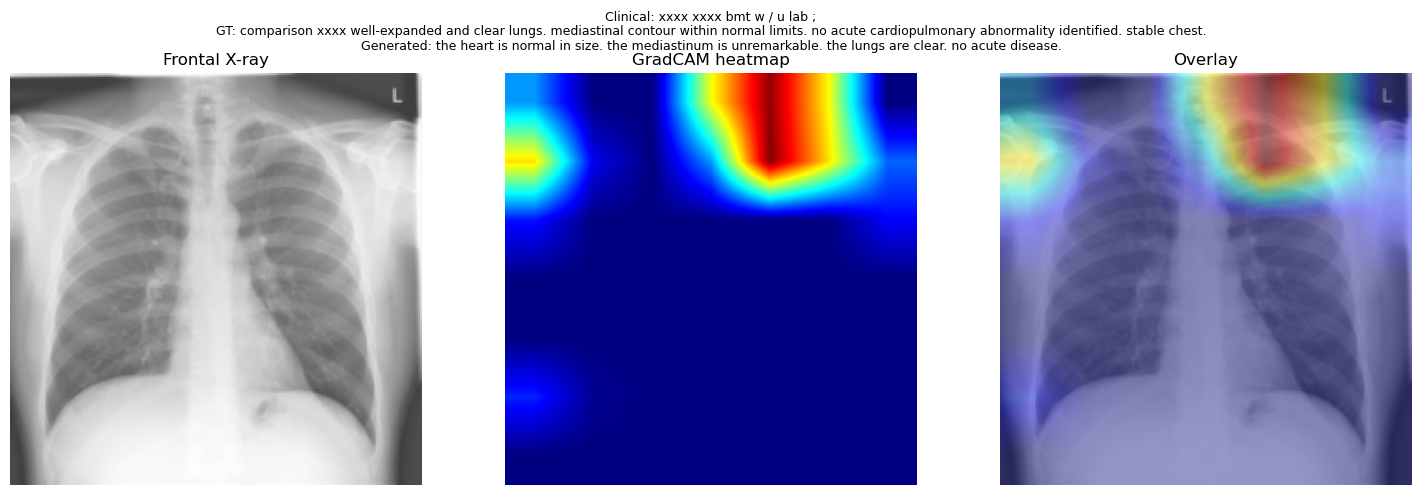

Sample idx: 494


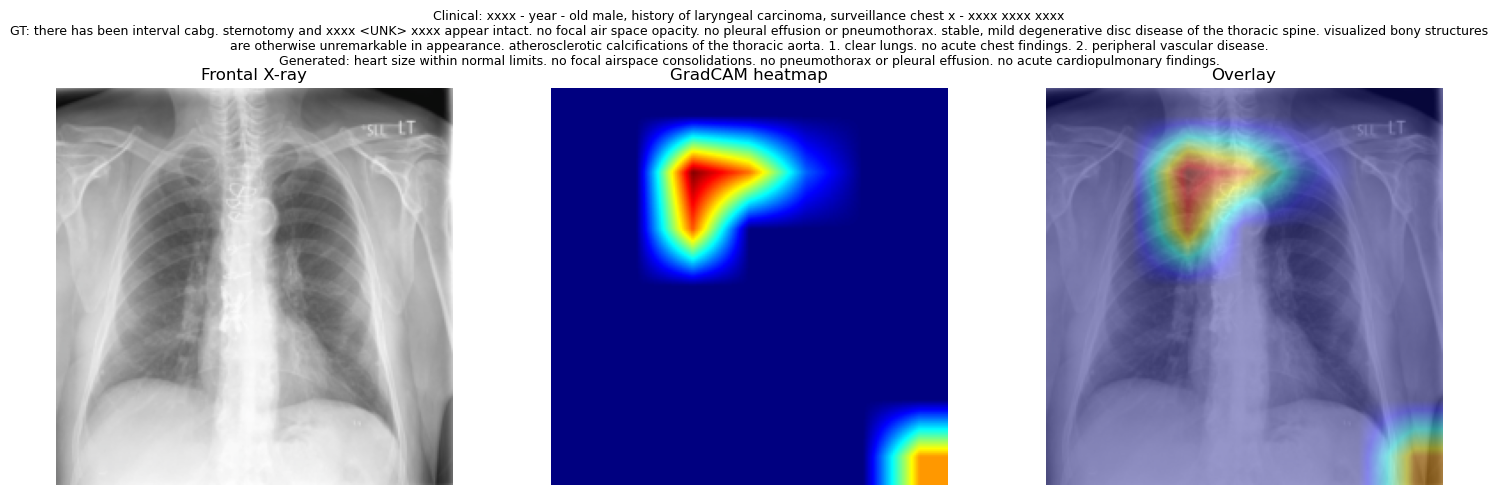

Sample idx: 356


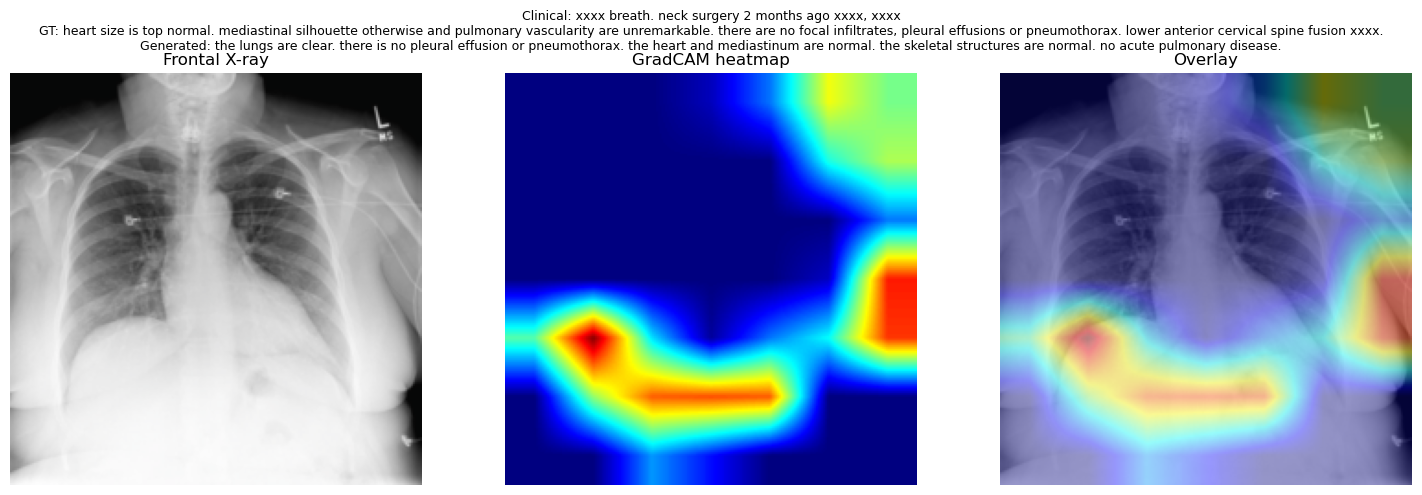

Sample idx: 210


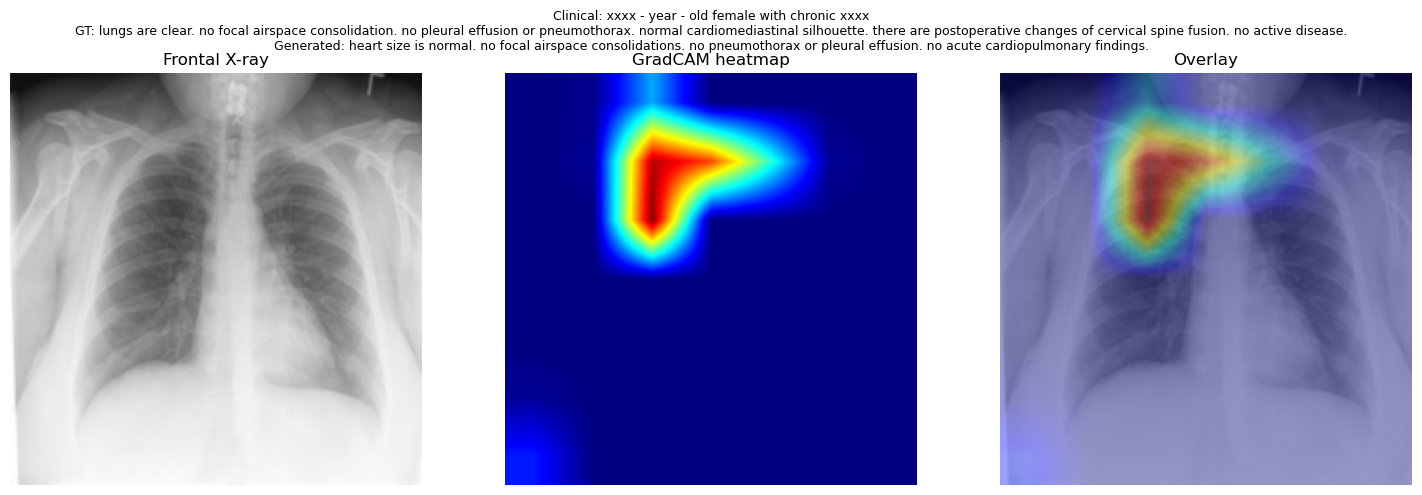

Sample idx: 224


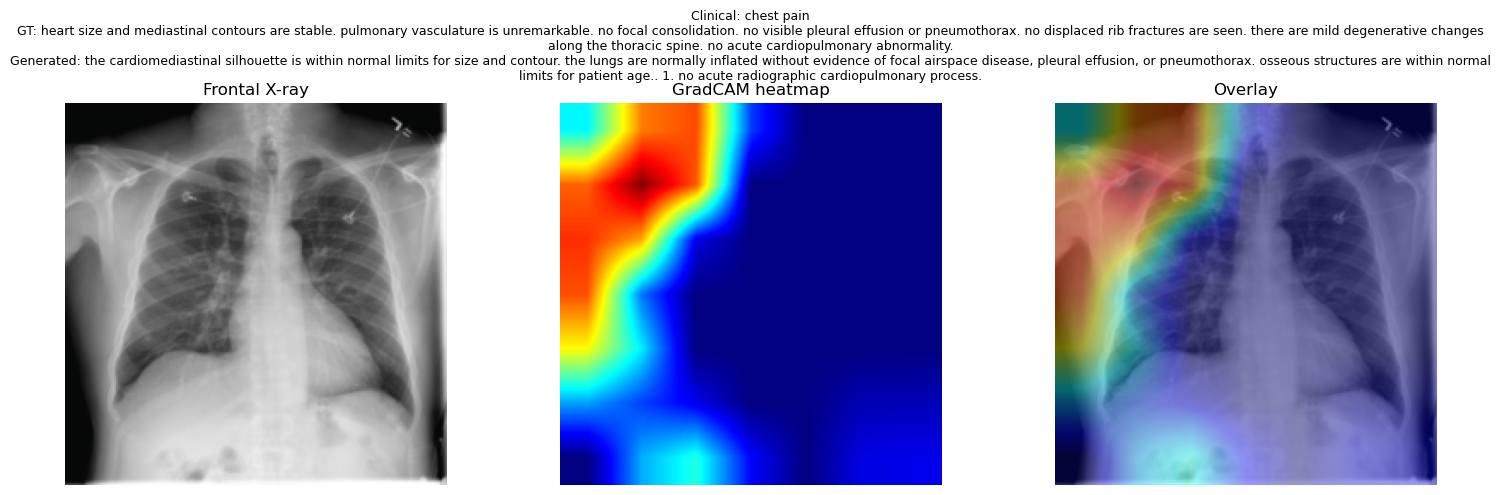

In [40]:
# Show 5 examples với index cố định
for idx in indices:
    print(f"Sample idx: {idx}")
    show_gradcam(model, test_dataset, vocab, idx=idx)